# Replicating the Effect of Batch Size on PPO Mean Reward

This notebook demonstrates how to replicate the plot showing the effect of different batch sizes on mean reward over time for PPO training.

1. Set up batch size experiments.
2. Train PPO models with different batch sizes.
3. Collect mean reward data over time.
4. Plot mean reward vs. time for each batch size.

## 1. Set Up Batch Size Experiments

We define a list of batch sizes and prepare the environment and PPO parameters for each batch size.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.gym.index_names import INVENTORY_INDEX, TIME_INDEX, ASSET_PRICE_INDEX 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import VecMonitor

# Import your custom environment setup
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.wrappers import ReduceStateSizeWrapper
from mbt_gym.gym.TradingEnvironment import TradingEnvironment


# PPO/environment parameters
num_trajectories = [10, 100]#, 1000]
n_steps = 100
total_timesteps = 1_000_000  # Adjust as needed for visible learning curves
policy_kwargs = dict(net_arch=[dict(pi=[128, 128], vf=[128, 128])])

seed=42

In [5]:
max_inventory = 20
terminal_time = 1
fill_exponent = 1
sigma = 0.1
initial_inventory = (-4,5)
arrival_rate = 10
initial_price = 100
step_size = 1/n_steps
timestamps = np.linspace(0, terminal_time, n_steps + 1)
phi = 0.5
alpha = 0.001

In [6]:
def get_env(num_trajectories:int = 1) -> TradingEnvironment:
    midprice_model = BrownianMotionMidpriceModel(volatility=sigma, step_size=1/n_steps,
                                                 num_trajectories=num_trajectories)
    arrival_model = PoissonArrivalModel(intensity=np.array([arrival_rate, arrival_rate]), 
                                        step_size=1/n_steps, 
                                        num_trajectories=num_trajectories)
    fill_probability_model = ExponentialFillFunction(fill_exponent=fill_exponent, 
                                                     step_size=1/n_steps,
                                                     num_trajectories=num_trajectories)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories)
    reward_function = CjMmCriterion(per_step_inventory_aversion = phi, terminal_inventory_aversion = alpha)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      max_inventory=n_steps,
                      normalise_action_space = True,
                      normalise_observation_space = True,
                      reward_function = reward_function,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [7]:
# Prepare environment function 
def make_env(num_trajectories=num_trajectories):
    env = ReduceStateSizeWrapper(get_env(num_trajectories), [INVENTORY_INDEX, TIME_INDEX])
    sb_env = StableBaselinesTradingEnvironment(trading_env=env)
    sb_env = VecMonitor(sb_env)
    return sb_env

## 2. Train PPO Models with Different Batch Sizes

For each batch size, we train a PPO model and log the mean reward at regular intervals.

In [8]:
# # Modify your plotting code to track and display wall-clock time
# import time

# # Add this to your RewardLoggerCallback class
# class RewardLoggerCallback(BaseCallback):
#     def __init__(self, log_interval=1000, verbose=0):
#         super().__init__(verbose)
#         self.log_interval = log_interval
#         self.mean_rewards = []
#         self.timesteps = []
#         self.wall_clock_times = []
#         self.start_time = None
#         self.episode_rewards = []
#         self.last_buffer_length = 0

#     def _on_training_start(self) -> None:
#         # ensure timer resets for each model.learn()
#         self.start_time = time.time()

#     def _on_step(self) -> bool:
#         if self.n_calls % self.log_interval == 0 and self.start_time is not None:
#             import time
#             elapsed_time = time.time() - self.start_time
#             if len(self.model.ep_info_buffer) > self.last_buffer_length:
#                 rewards = [ep_info["r"] for ep_info in self.model.ep_info_buffer]
#                 self.last_buffer_length = len(self.model.ep_info_buffer)
#                 if rewards:
#                     mean_reward = np.mean(rewards)
#                     self.mean_rewards.append(mean_reward)
#                     self.timesteps.append(self.num_timesteps)
#                     self.wall_clock_times.append(elapsed_time)
#                     print(f"Step {self.num_timesteps} | {elapsed_time:.1f}s | mean R {mean_reward:.3f}")
#         return True

# results = {}

# for num_trajectory in num_trajectories:
#     print(f"Training PPO with num_trajectory={num_trajectory}")
#     env = make_env(num_trajectory)

#     PPO_params = {
#         "policy": "MlpPolicy",
#         "env": env,
#         "verbose": 1,
#         "policy_kwargs": policy_kwargs,
#         "batch_size": n_steps * num_trajectory, 
#         "n_epochs": 1,
#         "n_steps": n_steps,
#     }
#     model = PPO(**PPO_params, tensorboard_log=None, device="cpu")
#     callback = RewardLoggerCallback(log_interval=1000)  # log more frequently
#     model.learn(total_timesteps=total_timesteps, callback=callback)
#     results[num_trajectory] = {
#         "timesteps": callback.timesteps,
#         "mean_rewards": callback.mean_rewards,
#         "wall_clock_times": callback.wall_clock_times, 
#    }

In [9]:
# ...existing code...
# Replace the RewardLoggerCallback and training loop cell with the following:

import time
from stable_baselines3.common.callbacks import BaseCallback

class RewardLoggerCallback(BaseCallback):
    def __init__(self, log_interval=200, verbose=0):
        super().__init__(verbose)
        self.log_interval = log_interval
        self.mean_rewards = []
        self.timesteps = []
        self.wall_clock_times = []
        self.start_time = None
        self.last_recorded_size = 0

    def _on_training_start(self) -> None:
        self.start_time = time.time()

    def _log_current_mean(self):
        if len(self.model.ep_info_buffer) == 0:
            return
        # Always recompute mean (cheap) so we don't miss the final one
        rewards = [ep["r"] for ep in self.model.ep_info_buffer]
        mean_reward = float(np.mean(rewards))
        elapsed = time.time() - self.start_time
        # Avoid duplicating identical lengths
        if len(self.model.ep_info_buffer) != self.last_recorded_size:
            self.mean_rewards.append(mean_reward)
            self.timesteps.append(self.num_timesteps)
            self.wall_clock_times.append(elapsed)
            self.last_recorded_size = len(self.model.ep_info_buffer)
            print(f"Step {self.num_timesteps} | {elapsed:.1f}s | mean R {mean_reward:.3f}")

    def _on_step(self) -> bool:
        if self.n_calls % self.log_interval == 0:
            self._log_current_mean()
        return True

    def _on_rollout_end(self):
        # Capture stats at end of each rollout
        self._log_current_mean()

    def _on_training_end(self):
        # Final flush in case last episodes ended at the final step
        self._log_current_mean()


results = {}

# Desired episodes per environment you want to see for each configuration
desired_episodes_per_env = 5

for num_trajectory in num_trajectories:
    rollout_size = n_steps * num_trajectory
    total_timesteps_adjusted = desired_episodes_per_env * n_steps * num_trajectory

    if total_timesteps < rollout_size:
        print(f"[Info] total_timesteps ({total_timesteps}) < rollout_size ({rollout_size}). "
              f"Adjusting to {total_timesteps_adjusted} to allow {desired_episodes_per_env} episodes per env.")
        effective_total = total_timesteps_adjusted
    else:
        # Ensure at least desired episodes even if user set a higher total_timesteps
        min_needed = desired_episodes_per_env * n_steps * num_trajectory
        effective_total = max(total_timesteps, min_needed)

    per_env_steps = effective_total // num_trajectory
    if per_env_steps < n_steps:
        print(f"[Warning] num_trajectory={num_trajectory}: per-env steps {per_env_steps} < episode length {n_steps}; "
              f"no episode will finish. Increasing total timesteps.")
        effective_total = (n_steps + 1) * num_trajectory

    print(f"Training PPO with num_trajectory={num_trajectory} "
          f"(n_envs={num_trajectory}) | rollout_size={rollout_size} | total_timesteps={effective_total}")

    env = make_env(num_trajectory)

    PPO_params = {
        "policy": "MlpPolicy",
        "env": env,
        "verbose": 0,
        "policy_kwargs": policy_kwargs,
        "batch_size": rollout_size,  # cap batch_size for efficiency
        "n_epochs": 1,
        "n_steps": n_steps,
    }

    model = PPO(**PPO_params, tensorboard_log=None, device="cpu")
    callback = RewardLoggerCallback(log_interval=min(200, n_steps // 5))
    model.learn(total_timesteps=effective_total, callback=callback)

    results[num_trajectory] = {
        "timesteps": callback.timesteps,
        "mean_rewards": callback.mean_rewards,
        "wall_clock_times": callback.wall_clock_times,
    }

Training PPO with num_trajectory=10 (n_envs=10) | rollout_size=1000 | total_timesteps=1000000


/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


Step 1000 | 0.0s | mean R -1.888
Step 2000 | 0.1s | mean R -5.390
Step 3000 | 0.1s | mean R -4.238
Step 4000 | 0.1s | mean R -3.274
Step 5000 | 0.1s | mean R -3.499
Step 6000 | 0.2s | mean R -3.246
Step 7000 | 0.2s | mean R -3.100
Step 8000 | 0.2s | mean R -3.152
Step 9000 | 0.3s | mean R -3.160
Step 10000 | 0.3s | mean R -2.991
Training PPO with num_trajectory=100 (n_envs=100) | rollout_size=10000 | total_timesteps=1000000
Step 10000 | 0.0s | mean R -1.387


/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


In [10]:
for n in num_trajectories:
    if results[n]["mean_rewards"]:
        print(f"{n}: last mean reward {results[n]['mean_rewards'][-1]:.2f} "
              f"points logged={len(results[n]['mean_rewards'])}")
    else:
        print(f"{n}: still no episode reward recorded (check episode termination logic).")

10: last mean reward -2.99 points logged=10
100: last mean reward -1.39 points logged=1


## 3. Collect Mean Reward Data Over Time

Mean reward data for each batch size is stored during training and will be used for plotting.

In [11]:
# Example: Print summary statistics for each trajectory
for num_trajectory in num_trajectories:
    if results[num_trajectory]['mean_rewards']:
        print(f"Num trajectories {num_trajectory}: Final mean reward = {results[num_trajectory]['mean_rewards'][-1]:.2f}")
    else:
        print(f"Num trajectories {num_trajectory}: No rewards collected during training")

Num trajectories 10: Final mean reward = -2.99
Num trajectories 100: Final mean reward = -1.39


## 4. Plot Mean Reward vs. Time for Each Batch Size

We plot the mean reward against time for each batch size on the same figure, with appropriate labels and legend.

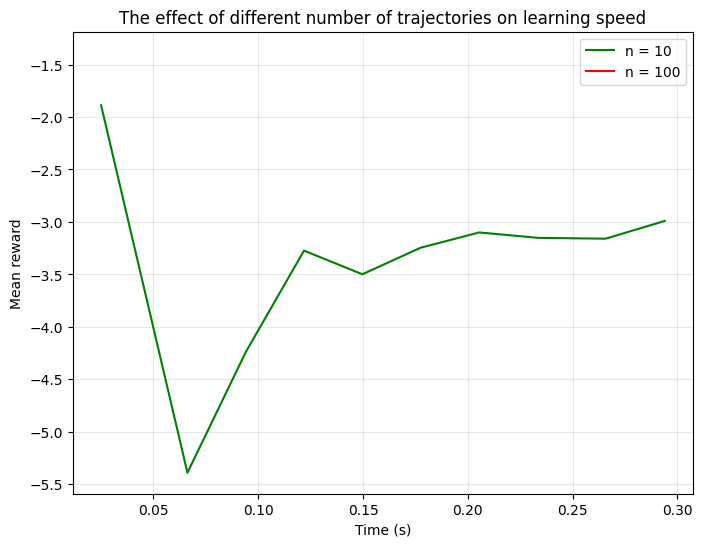

In [12]:
plt.figure(figsize=(8,6))
colors = ['green', 'red', 'blue', 'black']
for idx, num_trajectory in enumerate(num_trajectories):
    wall_clock_times = results[num_trajectory]['wall_clock_times']
    mean_rewards = results[num_trajectory]['mean_rewards']
    plt.plot(wall_clock_times, mean_rewards, label=f"n = {num_trajectory}", color=colors[idx])

plt.xlabel("Time (s)")
plt.ylabel("Mean reward")
plt.title("The effect of different number of trajectories on learning speed")
plt.legend()
plt.grid(alpha=0.3)